In [1]:
import pandas as pd
from factor_analyzer import FactorAnalyzer
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import datetime

In [2]:
df = pd.read_csv("./Customer data-1.csv", index_col='ID')
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,04/09/2012,58,635,88,...,7,0,0,0,0,0,0,3,11,1
2174,1954,Graduation,Single,46344.0,1,1,08/03/2014,38,11,1,...,5,0,0,0,0,0,0,3,11,0
4141,1965,Graduation,Together,71613.0,0,0,21/08/2013,26,426,49,...,4,0,0,0,0,0,0,3,11,0
6182,1984,Graduation,Together,26646.0,1,0,10/02/2014,26,11,4,...,6,0,0,0,0,0,0,3,11,0
5324,1981,PhD,Married,58293.0,1,0,19/01/2014,94,173,43,...,5,0,0,0,0,0,0,3,11,0


In [3]:
current_year = datetime.datetime.now().year
df['Age'] = current_year - df['Year_Birth']

In [4]:
cols_to_drop = [
    'Education', 'Year_Birth', 'Marital_Status', 'Dt_Customer', # Text/Date Categories
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', # Binary Campaign Flags
    'AcceptedCmp4', 'AcceptedCmp5', 'Response',      # Binary Campaign Flags
    'Complain',                                     # Binary Flag
    'Z_CostContact', 'Z_Revenue'                    # Constants (if present)
]

df = df.drop(columns=cols_to_drop, errors='ignore')
df

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age
ID,,,,,,,,,,,,,,,,
5524,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,69
2174,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,72
4141,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,61
6182,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,42
5324,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10870,61223.0,0,1,46,709,43,182,42,118,247,2,9,3,4,5,59
4001,64014.0,2,1,56,406,0,30,0,0,8,7,8,2,5,7,80
7270,56981.0,0,0,91,908,48,217,32,12,24,1,2,3,13,6,45


In [5]:
df.mean()

Income                 52247.251354
Kidhome                    0.444196
Teenhome                   0.506250
Recency                   49.109375
MntWines                 303.935714
MntFruits                 26.302232
MntMeatProducts          166.950000
MntFishProducts           37.525446
MntSweetProducts          27.062946
MntGoldProds              44.021875
NumDealsPurchases          2.325000
NumWebPurchases            4.084821
NumCatalogPurchases        2.662054
NumStorePurchases          5.790179
NumWebVisitsMonth          5.316518
Age                       57.194196
dtype: float64

In [6]:
df.var()

Income                 6.336838e+08
Kidhome                2.898725e-01
Teenhome               2.965219e-01
Recency                8.388237e+02
MntWines               1.132978e+05
MntFruits              1.581926e+03
MntMeatProducts        5.094743e+04
MntFishProducts        2.984325e+03
MntSweetProducts       1.704080e+03
MntGoldProds           2.721442e+03
NumDealsPurchases      3.733542e+00
NumWebPurchases        7.721252e+00
NumCatalogPurchases    8.544517e+00
NumStorePurchases      1.056873e+01
NumWebVisitsMonth      5.888606e+00
Age                    1.436179e+02
dtype: float64

In [7]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

feature_names = df.columns.tolist()
df = pd.DataFrame(df_scaled, columns=feature_names)
df

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age
0,0.234063,-0.825218,-0.929894,0.307039,0.983781,1.551577,1.679702,2.462147,1.476500,0.843207,0.349414,1.409304,2.510890,-0.550785,0.693904,0.985345
1,-0.234559,1.032559,0.906934,-0.383664,-0.870479,-0.636301,-0.713225,-0.650449,-0.631503,-0.729006,-0.168236,-1.110409,-0.568720,-1.166125,-0.130463,1.235733
2,0.769478,-0.825218,-0.929894,-0.798086,0.362723,0.570804,-0.177032,1.345274,-0.146905,-0.038766,-0.685887,1.409304,-0.226541,1.295237,-0.542647,0.317643
3,-1.017239,1.032559,-0.929894,-0.798086,-0.870479,-0.560857,-0.651187,-0.503974,-0.583043,-0.748179,-0.168236,-0.750450,-0.910898,-0.550785,0.281720,-1.268149
4,0.240221,1.032559,-0.929894,1.550305,-0.389085,0.419916,-0.216914,0.155164,-0.001525,-0.556446,1.384715,0.329427,0.115638,0.064556,-0.130463,-1.017761
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,0.356642,-0.825218,0.906934,-0.107383,1.203678,0.419916,0.066692,0.081926,2.203398,3.891766,-0.168236,1.769263,0.115638,-0.550785,-0.130463,0.150717
2236,0.467539,2.890335,0.906934,0.237969,0.303291,-0.661449,-0.606873,-0.687068,-0.655733,-0.690659,2.420015,1.409304,-0.226541,-0.243114,0.693904,1.903435
2237,0.188091,-0.825218,-0.929894,1.446700,1.795020,0.545656,0.221789,-0.101168,-0.364974,-0.383886,-0.685887,-0.750450,0.115638,2.218248,0.281720,-1.017761
2238,0.675388,-0.825218,0.906934,-1.419719,0.368666,0.092992,0.208495,0.777683,0.071165,0.325527,-0.168236,0.689386,0.799996,1.295237,-0.954831,1.068807


In [8]:
# Drop rows where any value is NaN
df = df.dropna()

In [9]:
df.isnull().sum()

Income                 0
Kidhome                0
Teenhome               0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Age                    0
dtype: int64

In [10]:
df.dtypes

Income                 float64
Kidhome                float64
Teenhome               float64
Recency                float64
MntWines               float64
MntFruits              float64
MntMeatProducts        float64
MntFishProducts        float64
MntSweetProducts       float64
MntGoldProds           float64
NumDealsPurchases      float64
NumWebPurchases        float64
NumCatalogPurchases    float64
NumStorePurchases      float64
NumWebVisitsMonth      float64
Age                    float64
dtype: object

In [11]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
chi_square_value, p_value =  calculate_bartlett_sphericity(df)
print(f"p-value: {p_value}")

p-value: 0.0


In [12]:
from factor_analyzer.factor_analyzer import calculate_kmo
kmo_all,kmo_model = calculate_kmo(df)
kmo_model

0.8874387167191792

In [13]:
kmo_all

array([0.92794007, 0.9047761 , 0.60436531, 0.3290392 , 0.8865127 ,
       0.93868807, 0.91155022, 0.93624743, 0.94241706, 0.93991639,
       0.5200107 , 0.86194667, 0.90393862, 0.89960907, 0.83795026,
       0.70708709])

In [14]:
fa = FactorAnalyzer(rotation=None)
fa.fit(df)

FactorAnalyzer(rotation=None, rotation_kwargs={})

In [15]:
loadings=fa.loadings_
loadings

array([[ 0.71880027,  0.06201538, -0.16808372],
       [-0.63356127, -0.07085825,  0.2274928 ],
       [-0.11576837,  0.66133955, -0.302889  ],
       [ 0.01242235,  0.00355908, -0.01166802],
       [ 0.72808592,  0.24462009,  0.03026731],
       [ 0.67141836, -0.15889354,  0.14919528],
       [ 0.7874112 , -0.18412299,  0.06030287],
       [ 0.69924908, -0.18002148,  0.14417982],
       [ 0.66934385, -0.13664032,  0.13758318],
       [ 0.53555876,  0.1232771 ,  0.16311324],
       [-0.11812138,  0.55880041,  0.24469892],
       [ 0.53437577,  0.49723041,  0.23941993],
       [ 0.79813169,  0.00835706,  0.00357782],
       [ 0.72108473,  0.22709158,  0.00981119],
       [-0.64254643,  0.3207028 ,  0.42871119],
       [ 0.14811213,  0.32318739, -0.36072557]])

In [16]:
ev,v = fa.get_eigenvalues()
ev

array([6.08807517, 1.95131849, 1.23008386, 1.00486761, 0.82750802,
       0.76508795, 0.64242326, 0.61630387, 0.48825976, 0.44979732,
       0.42356372, 0.38981891, 0.35618118, 0.30542762, 0.24487974,
       0.2164035 ])

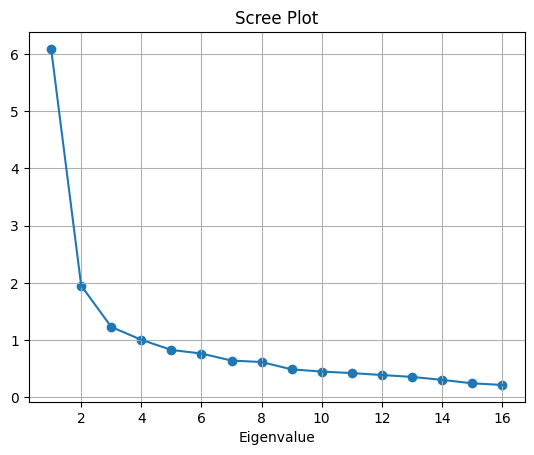

In [17]:
plt.scatter(range(1,df.shape[1]+1),ev)
plt.plot(range(1,df.shape[1]+1),ev)
plt.title('Scree Plot')
plt.xlabel('Factors')
plt.xlabel('Eigenvalue')
plt.grid()
plt.show()

In [18]:
fa =  FactorAnalyzer(n_factors=4, rotation="varimax")
fa.fit(df)
loadings=fa.loadings_
loadings

array([[ 5.68544200e-01,  3.63156810e-01, -2.03140257e-01,
         2.44047796e-01],
       [-4.78187182e-01, -3.21452388e-01,  1.98889975e-01,
        -2.76032233e-01],
       [-8.71103334e-02, -1.55469175e-01,  4.16991704e-01,
         7.96982854e-01],
       [ 5.84909021e-03,  7.06203166e-03, -6.28452641e-03,
         1.55192293e-02],
       [ 8.26278235e-01,  2.38530355e-01,  4.36156361e-02,
         1.08734003e-01],
       [ 2.61711228e-01,  7.02639984e-01, -1.23970525e-01,
        -6.68227187e-04],
       [ 5.67907856e-01,  5.09709971e-01, -2.71067914e-01,
        -3.85252186e-02],
       [ 2.76864121e-01,  7.22858358e-01, -1.49649376e-01,
        -6.37295194e-03],
       [ 2.84114698e-01,  6.71383274e-01, -1.18056480e-01,
         1.28475148e-02],
       [ 3.46150155e-01,  4.50244864e-01,  1.04772695e-01,
         6.23388654e-02],
       [ 3.18253336e-02, -7.08042102e-02,  5.88888841e-01,
         1.21076316e-01],
       [ 5.44713272e-01,  3.08553694e-01,  4.14267483e-01,
      

In [19]:
pd.DataFrame.from_records(loadings)

,0,1,2,3
0,0.568544,0.363157,-0.203140,0.244048
1,-0.478187,-0.321452,0.198890,-0.276032
2,-0.087110,-0.155469,0.416992,0.796983
3,0.005849,0.007062,-0.006285,0.015519
4,0.826278,0.238530,0.043616,0.108734
5,0.261711,0.702640,-0.123971,-0.000668
6,0.567908,0.509710,-0.271068,-0.038525
7,0.276864,0.722858,-0.149649,-0.006373
8,0.284115,0.671383,-0.118056,0.012848
9,0.346150,0.450245,0.104773,0.062339


In [20]:
fa =  FactorAnalyzer(n_factors=3, rotation="varimax")
fa.fit(df)
loadings=fa.loadings_
loadings

array([[ 0.64347053, -0.15353669,  0.33338271],
       [-0.54514006,  0.16224624, -0.36697714],
       [-0.18372968,  0.4219558 ,  0.57507458],
       [ 0.00870121, -0.00503759,  0.01421394],
       [ 0.71168754,  0.1002844 ,  0.27259512],
       [ 0.68311414, -0.16962812, -0.05376223],
       [ 0.76889349, -0.25569586,  0.03124935],
       [ 0.70800029, -0.19464548, -0.05471339],
       [ 0.67827907, -0.15645978, -0.03284412],
       [ 0.56206383,  0.09802497,  0.05569304],
       [-0.03380541,  0.61591424,  0.07479948],
       [ 0.58952812,  0.45249795,  0.19447276],
       [ 0.7668767 , -0.12422248,  0.18320958],
       [ 0.69887902,  0.07621448,  0.27818968],
       [-0.48966579,  0.59673813, -0.32193244],
       [ 0.04671305,  0.06330148,  0.50032094]])

In [21]:
pd.DataFrame.from_records(loadings)

,0,1,2
0,0.643471,-0.153537,0.333383
1,-0.545140,0.162246,-0.366977
2,-0.183730,0.421956,0.575075
3,0.008701,-0.005038,0.014214
4,0.711688,0.100284,0.272595
5,0.683114,-0.169628,-0.053762
6,0.768893,-0.255696,0.031249
7,0.708000,-0.194645,-0.054713
8,0.678279,-0.156460,-0.032844
9,0.562064,0.098025,0.055693


In [22]:
df.columns

Index(['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Age'],
      dtype='str')

In [23]:
import pingouin as pg

factor1_items = df[['Income', 'MntWines', 'MntMeatProducts', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']]

alpha_tuple = pg.cronbach_alpha(data=factor1_items)

print(f"Cronbach's Alpha for Factor 1: {alpha_tuple[0]:.3f}")

Cronbach's Alpha for Factor 1: 0.873


In [24]:
factor2_items = df[['MntFruits', 'MntFishProducts', 'MntMeatProducts', 'MntSweetProducts']]

alpha_tuple = pg.cronbach_alpha(data=factor2_items)

print(f"Cronbach's Alpha for Factor 1: {alpha_tuple[0]:.3f}")

Cronbach's Alpha for Factor 1: 0.840


In [25]:
factor3_items = df[['NumDealsPurchases', 'NumWebVisitsMonth']]

alpha_tuple = pg.cronbach_alpha(data=factor3_items)

print(f"Cronbach's Alpha for Factor 1: {alpha_tuple[0]:.3f}")

Cronbach's Alpha for Factor 1: 0.514


In [26]:
fa = FactorAnalyzer(n_factors=4, rotation="varimax")
fa.fit(df)

factor_scores = fa.transform(df)

df_factors = pd.DataFrame(
    factor_scores, 
    columns=['Factor_1', 'Factor_2', 'Factor_3', 'Factor_4'], 
    index=df.index
)

df_factors.head()

,Factor_1,Factor_2,Factor_3,Factor_4
0,0.832296,1.799296,0.711190,-0.996736
1,-0.930472,-0.658849,-0.399431,0.900639
2,0.504933,0.601094,-0.176542,-0.397312
3,-0.728214,-0.464099,-0.279334,-1.018743
4,-0.115401,0.315404,0.198652,-0.964912


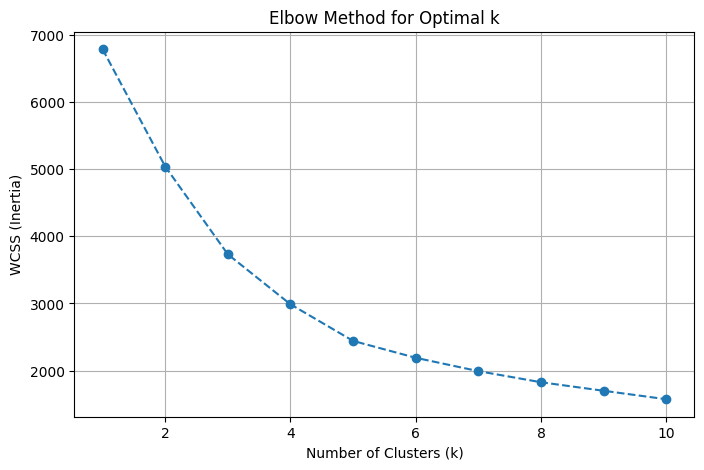

In [27]:
from sklearn.cluster import KMeans

wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_factors)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.grid(True)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal k')
plt.show()

In [28]:
optimal_k = 4

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_factors['Customer_Segment'] = kmeans_final.fit_predict(df_factors)

print("Customers per segment:")
print(df_factors['Customer_Segment'].value_counts())

df_factors.groupby('Customer_Segment').mean()

Customers per segment:
Customer_Segment
3    623
0    582
1    524
2    487
Name: count, dtype: int64


,Factor_1,Factor_2,Factor_3,Factor_4
Customer_Segment,,,,
0,-0.648584,-0.395772,-0.024607,0.871138
1,0.780505,0.965045,-0.784149,-0.242907
2,0.707902,-0.062064,0.977128,0.553067
3,-0.603944,-0.393449,-0.081294,-1.041834


Calculating statistical metrics for K=2 to 10...


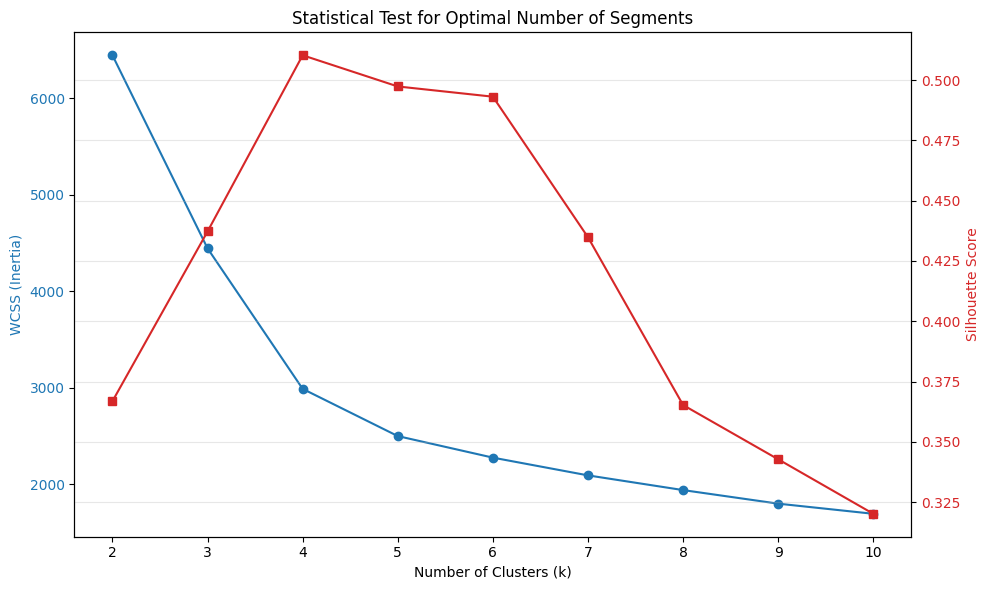

Optimal K suggested by largest reduction in WCSS: 4
Optimal K suggested by highest Silhouette Score: 4


In [29]:
from sklearn.metrics import silhouette_score
import numpy as np

cluster_data = df_factors.copy()

wcss = []
silhouette_avg = []
k_range = range(2, 11)

print("Calculating statistical metrics for K=2 to 10...")

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(cluster_data)
    
    wcss.append(kmeans.inertia_)
    
    silhouette_avg.append(silhouette_score(cluster_data, cluster_labels))

fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Inertia)', color=color)
ax1.plot(k_range, wcss, marker='o', color=color, label='WCSS')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, silhouette_avg, marker='s', color=color, label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Statistical Test for Optimal Number of Segments')
plt.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

diffs = np.diff(wcss)
diff_ratios = diffs[1:] / diffs[:-1]
print(f"Optimal K suggested by largest reduction in WCSS: {np.argmin(diff_ratios) + 3}")
print(f"Optimal K suggested by highest Silhouette Score: {k_range[np.argmax(silhouette_avg)]}")